# Loan Default Prediction (Entire Pipeline)

In [1]:
import sys
from pathlib import Path


PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


import pandas as pd
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from src.preprocessing import HardOutlierFilters, DataPreprocessing, XGBoostPreprocessing, NeuralNetworkCleanDataNormalizer, NeuralNetworkSmoteDataNormalizer
from src.model.extreme_gradient_boosting import BaseModelXGBoost, WeightedXGBoost
from src.model.neural_network import NeuralNetwork, SmoteNeuralNetwork
from src.model.quantum import QELMIsing
from src.fairness import FairnessEnhancedModel, SampleWeightedMLPClassifier
from src.config import NORMALIZE_NEURAL_NETWORK_CLEAN_DATA_CONFIG, NORMALIZE_NEURAL_NETWORK_SMOTE_DATA_CONFIG
from src.config import MODEL_NEURAL_NETWORK_CLEAN_DATA_CONFIG, MODEL_NEURAL_NETWORK_SMOTE_DATA_CONFIG


RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
DATA_DIR = PROJECT_ROOT / "data" / "pre-processed"

## Preprocessing

In [2]:
raw_df = pd.read_csv(RAW_DATA_DIR / "loan_data.csv")
HardOutlierFilters(raw_df).run()

hard_filtered_df = pd.read_csv(DATA_DIR / "loan_data_hard_filtered.csv")
DataPreprocessing(hard_filtered_df).run()

preprocessed_df = pd.read_csv(DATA_DIR / "loan_data_preprocessed.csv")

## XGBoost

In [3]:
XGBoostPreprocessing(preprocessed_df).run()
test_df = pd.read_csv(DATA_DIR / "loan_data_raw_test_1.csv")
clean_train_df = pd.read_csv(DATA_DIR / "loan_data_clean_train_3.csv")
smoted_train_df = pd.read_csv(DATA_DIR / "loan_data_smoted_raw_train_4.csv")

In [4]:
print("\n\nBaseline XGBOOST:\n")
baseline_xgboost = BaseModelXGBoost(clean_train_df, test_df)
baseline_xgboost.run()



Baseline XGBOOST:

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV F1 score: 0.7771450631700421
Best parameters:
{'model__colsample_bytree': np.float64(0.8469659942717966), 'model__gamma': np.float64(0.2923526115115946), 'model__learning_rate': np.float64(0.09424711004186694), 'model__max_depth': 9, 'model__min_child_weight': 5, 'model__n_estimators': 417, 'model__reg_alpha': np.float64(0.10938210978653512), 'model__reg_lambda': np.float64(2.6162040040346826), 'model__subsample': np.float64(0.848652149079867)}

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      6999
           1       0.88      0.70      0.78      2000

    accuracy                           0.91      8999
   macro avg       0.90      0.84      0.86      8999
weighted avg       0.91      0.91      0.91      8999


Confusion matrix: Row: Actual class, Column: Predicted class
[[6812  187]
 [ 599 1401]]

By-class accuracy:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['person_age','person_gender','person_education',...,'loan_percent_income', 'cb_person_cred_hist_length','credit_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [5]:
print("\n\nSmote XGBOOST:\n")
smote_xgboost = BaseModelXGBoost(smoted_train_df, test_df)
smote_xgboost.run()



Smote XGBOOST:

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV F1 score: 0.9421408999509817
Best parameters:
{'model__colsample_bytree': np.float64(0.8273470692601075), 'model__gamma': np.float64(0.37785549605785707), 'model__learning_rate': np.float64(0.0823768849731394), 'model__max_depth': 9, 'model__min_child_weight': 3, 'model__n_estimators': 516, 'model__reg_alpha': np.float64(0.10453581036885684), 'model__reg_lambda': np.float64(2.582895947655132), 'model__subsample': np.float64(0.898283347888664)}

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      6999
           1       0.87      0.72      0.79      2000

    accuracy                           0.91      8999
   macro avg       0.90      0.85      0.87      8999
weighted avg       0.91      0.91      0.91      8999


Confusion matrix: Row: Actual class, Column: Predicted class
[[6783  216]
 [ 558 1442]]

By-class accuracy:
Clas

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['person_age','person_gender','person_education',...,'loan_percent_income', 'cb_person_cred_hist_length','credit_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [6]:
print("\n\nWeighted XGBOOST:\n")
weighted_xgboost = WeightedXGBoost(clean_train_df, test_df)
weighted_xgboost.run()



Weighted XGBOOST:

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV F1 score: 0.7771652757595972
Best parameters:
{'model__colsample_bytree': np.float64(0.8764611661187159), 'model__gamma': np.float64(0.27173539876631314), 'model__learning_rate': np.float64(0.11821972156672828), 'model__max_depth': 9, 'model__min_child_weight': 3, 'model__n_estimators': 500, 'model__reg_alpha': np.float64(0.16039003248586792), 'model__reg_lambda': np.float64(1.8730370207997085), 'model__scale_pos_weight': np.float64(1.948290034151737), 'model__subsample': np.float64(0.8804518003420011)}

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94      6999
           1       0.84      0.74      0.79      2000

    accuracy                           0.91      8999
   macro avg       0.89      0.85      0.86      8999
weighted avg       0.91      0.91      0.91      8999


Confusion matrix: Row: Actual class, Column: Pre

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['person_age','person_gender','person_education',...,'loan_percent_income', 'cb_person_cred_hist_length','credit_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

## Neural Network

In [7]:
NeuralNetworkCleanDataNormalizer(clean_train_df, test_df).run()
NeuralNetworkSmoteDataNormalizer(smoted_train_df, test_df).run()
nn_train_df = pd.read_csv(DATA_DIR / NORMALIZE_NEURAL_NETWORK_CLEAN_DATA_CONFIG["train_output_filename"])
nn_test_df = pd.read_csv(DATA_DIR / NORMALIZE_NEURAL_NETWORK_CLEAN_DATA_CONFIG["test_output_filename"])
nn_smote_train_df = pd.read_csv(DATA_DIR / NORMALIZE_NEURAL_NETWORK_SMOTE_DATA_CONFIG["train_output_filename"])
nn_smote_test_df = pd.read_csv(DATA_DIR / NORMALIZE_NEURAL_NETWORK_SMOTE_DATA_CONFIG["test_output_filename"])

In [8]:
print("\n\nBaseline Neural Network:\n")
baseline_neural_network = NeuralNetwork(nn_train_df, nn_test_df, config=MODEL_NEURAL_NETWORK_CLEAN_DATA_CONFIG)
baseline_neural_network.run()



Baseline Neural Network:

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV F1 score: 0.7269025968002472
Best parameters:
{'model__activation': 'tanh', 'model__alpha': np.float64(5.108188686258303e-05), 'model__batch_size': 128, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': np.float64(0.000456088071202065)}

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94      6999
           1       0.86      0.63      0.73      2000

    accuracy                           0.90      8999
   macro avg       0.88      0.80      0.83      8999
weighted avg       0.89      0.90      0.89      8999


Confusion matrix: Row: Actual class, Column: Predicted class
[[6794  205]
 [ 737 1263]]

By-class accuracy:
Class 0: 0.9707
Class 1: 0.6315

Summary metrics (Test):
Accuracy: 0.8953
F1-score: 0.7284
Precision: 0.8604
Recall: 0.6315
TPR: 0.6315
TNR: 0.9707
FPR: 0.0293
FNR: 0.3685
Saved model to

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['person_age','person_income','person_emp_exp',...,'loan_intent_MEDICAL', 'loan_intent_PERSONAL','loan_intent_VENTURE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",np.float64(5....686258303e-05)


In [9]:
print("\n\nSmote Neural Network:\n")
smote_neural_network = SmoteNeuralNetwork(nn_smote_train_df, nn_smote_test_df, config=MODEL_NEURAL_NETWORK_SMOTE_DATA_CONFIG)
smote_neural_network.run()



Smote Neural Network:

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV F1 score: 0.8542980450614204
Best parameters:
{'model__activation': 'tanh', 'model__alpha': np.float64(5.108188686258303e-05), 'model__batch_size': 128, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': np.float64(0.000456088071202065)}

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.90      6999
           1       0.62      0.75      0.68      2000

    accuracy                           0.84      8999
   macro avg       0.77      0.81      0.79      8999
weighted avg       0.86      0.84      0.85      8999


Confusion matrix: Row: Actual class, Column: Predicted class
[[6074  925]
 [ 493 1507]]

By-class accuracy:
Class 0: 0.8678
Class 1: 0.7535

Summary metrics (Test):
Accuracy: 0.8424
F1-score: 0.6801
Precision: 0.6197
Recall: 0.7535
TPR: 0.7535
TNR: 0.8678
FPR: 0.1322
FNR: 0.2465
Saved model to: C

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](21,)","['person_age','person_income','person_emp_exp',...,'loan_intent_MEDICAL', 'loan_intent_PERSONAL','loan_intent_VENTURE']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,21
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",np.float64(5....686258303e-05)


## Quantum

In [10]:
qelm_train_df, qelm_test_df = QELMIsing().run()
qelm_feature_columns = []
for column in qelm_train_df.columns:
    if column != "loan_status":
        qelm_feature_columns.append(column)

qelm_scaler = StandardScaler()
qelm_nn_train_df = qelm_train_df.copy()
qelm_nn_test_df = qelm_test_df.copy()
qelm_nn_train_df[qelm_feature_columns] = qelm_scaler.fit_transform(qelm_train_df[qelm_feature_columns])
qelm_nn_test_df[qelm_feature_columns] = qelm_scaler.transform(qelm_test_df[qelm_feature_columns])

QELM output already exists, skipping quantum simulation: loan_data_qelm_ising_train.csv, loan_data_qelm_ising_test.csv


In [11]:
print("\n\nQuantum Smote XGBoost:\n")
qelm_smote_xgboost = BaseModelXGBoost(qelm_train_df, qelm_test_df)
qelm_smote_xgboost.run()



Quantum Smote XGBoost:

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV F1 score: 0.9205010006108267
Best parameters:
{'model__colsample_bytree': np.float64(0.8273470692601075), 'model__gamma': np.float64(0.37785549605785707), 'model__learning_rate': np.float64(0.0823768849731394), 'model__max_depth': 9, 'model__min_child_weight': 3, 'model__n_estimators': 516, 'model__reg_alpha': np.float64(0.10453581036885684), 'model__reg_lambda': np.float64(2.582895947655132), 'model__subsample': np.float64(0.898283347888664)}

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93      6999
           1       0.81      0.70      0.75      2000

    accuracy                           0.90      8999
   macro avg       0.86      0.83      0.84      8999
weighted avg       0.89      0.90      0.89      8999


Confusion matrix: Row: Actual class, Column: Predicted class
[[6663  336]
 [ 602 1398]]

By-class accura

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](78,)","['z_0','z_1','z_2',...,'zz_9_10','zz_9_11','zz_10_11']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,78
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns t

In [12]:
print("\n\nQuantum Smote Neural Network:\n")
qelm_smote_neural_network = SmoteNeuralNetwork(qelm_nn_train_df, qelm_nn_test_df, config={"model_filename": "neural_network_qelm_smote.joblib"})
qelm_smote_neural_network.run()



Quantum Smote Neural Network:

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV F1 score: 0.8393516723498976
Best parameters:
{'model__activation': 'relu', 'model__alpha': np.float64(0.00015498955191377127), 'model__batch_size': 256, 'model__hidden_layer_sizes': (128, 64), 'model__learning_rate_init': np.float64(0.0005154646722563058)}

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      6999
           1       0.61      0.71      0.65      2000

    accuracy                           0.83      8999
   macro avg       0.76      0.79      0.77      8999
weighted avg       0.84      0.83      0.84      8999


Confusion matrix: Row: Actual class, Column: Predicted class
[[6075  924]
 [ 578 1422]]

By-class accuracy:
Class 0: 0.8680
Class 1: 0.7110

Summary metrics (Test):
Accuracy: 0.8331
F1-score: 0.6544
Precision: 0.6061
Recall: 0.7110
TPR: 0.7110
TNR: 0.8680
FPR: 0.1320
FNR: 0.2890
Saved m

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](78,)","['z_0','z_1','z_2',...,'zz_9_10','zz_9_11','zz_10_11']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,78
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",np.float64(0....8955191377127)
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",256


## Fairness

In [13]:
fairness_train_df = clean_train_df.copy()
fairness_test_df = test_df.copy()
categorical_cols = fairness_train_df.drop(columns=["loan_status"]).select_dtypes(include=["object", "category", "string"]).columns
for col in categorical_cols:
    fairness_train_df[col] = fairness_train_df[col].astype("category")
    fairness_test_df[col] = fairness_test_df[col].astype("category")

fairness_smote_train_df = smoted_train_df.copy()
fairness_smote_test_df = test_df.copy()
for col in categorical_cols:
    fairness_smote_train_df[col] = fairness_smote_train_df[col].astype("category")
    fairness_smote_test_df[col] = fairness_smote_test_df[col].astype("category")


def tuned_xgboost_estimator(base_model):
    estimator = XGBClassifier()
    for param_name, param_value in base_model.get_best_model_params().items():
        setattr(estimator, param_name, param_value)

    estimator.enable_categorical = True
    return estimator


def tuned_nn_estimator(base_model):
    params = dict(base_model.get_best_model_params())
    random_state = params.pop("random_state", None)
    return SampleWeightedMLPClassifier(mlp_kwargs=params, random_state=random_state)



Fairness Baseline XGBOOST:

Summary metrics (Test):
Accuracy: 0.9081
F1-score: 0.7563
Precision: 0.9210
Recall: 0.6415
TPR: 0.6415
TNR: 0.9843
FPR: 0.0157
FNR: 0.3585


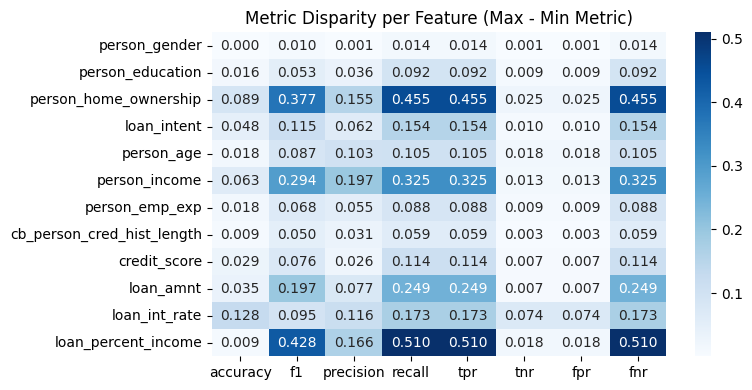

In [14]:
print("\n\nFairness Baseline XGBOOST:\n")
fairness_xgboost_estimator = tuned_xgboost_estimator(baseline_xgboost)
fairness_xgboost_model = FairnessEnhancedModel(fairness_train_df, fairness_test_df, fairness_xgboost_estimator,
                                               needs_encoding=False, model_name="xgboost", max_iter=20, show_plot=True)
fairness_xgboost_model.run()



Fairness SMOTE XGBOOST:

Summary metrics (Test):
Accuracy: 0.9151
F1-score: 0.7810
Precision: 0.9153
Recall: 0.6810
TPR: 0.6810
TNR: 0.9820
FPR: 0.0180
FNR: 0.3190


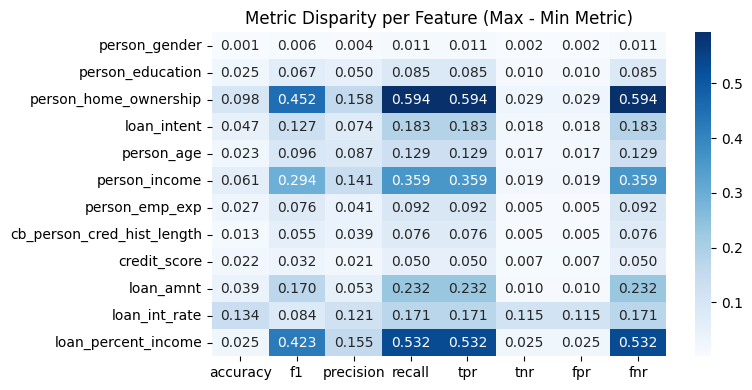

In [15]:
print("\n\nFairness SMOTE XGBOOST:\n")
fairness_smote_xgboost_estimator = tuned_xgboost_estimator(smote_xgboost)
fairness_smote_xgboost_model = FairnessEnhancedModel(fairness_smote_train_df, fairness_smote_test_df, fairness_smote_xgboost_estimator,
                                                     needs_encoding=False, model_name="xgboost_smote", max_iter=20, show_plot=True)
fairness_smote_xgboost_model.run()



Fairness QELM + Smote XGBOOST:

Summary metrics (Test):
Accuracy: 0.8985
F1-score: 0.7417
Precision: 0.8541
Recall: 0.6555
TPR: 0.6555
TNR: 0.9680
FPR: 0.0320
FNR: 0.3445


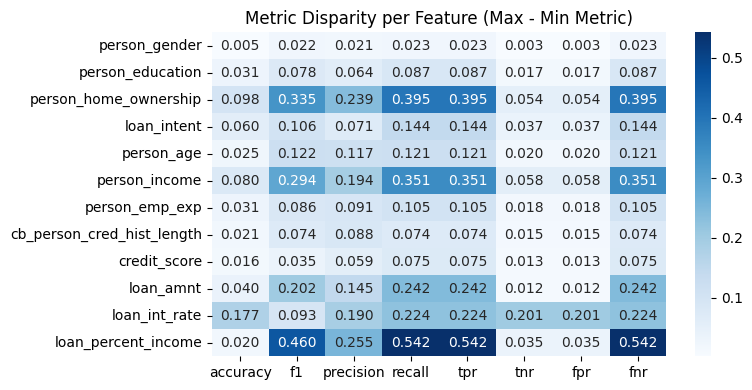

In [16]:
print("\n\nFairness QELM + Smote XGBOOST:\n")
fairness_qelm_xgboost_estimator = tuned_xgboost_estimator(qelm_smote_xgboost)
fairness_qelm_xgboost_model = FairnessEnhancedModel(qelm_train_df, qelm_test_df, fairness_qelm_xgboost_estimator,
                                                    sensitive_source_train_df=smoted_train_df,
                                                    sensitive_source_test_df=test_df,
                                                    needs_encoding=False, model_name="qelm_xgboost", max_iter=20, show_plot=True)
fairness_qelm_xgboost_model.run()



Fairness Baseline Neural Network:

Summary metrics (Test):
Accuracy: 0.8693
F1-score: 0.6228
Precision: 0.8685
Recall: 0.4855
TPR: 0.4855
TNR: 0.9790
FPR: 0.0210
FNR: 0.5145


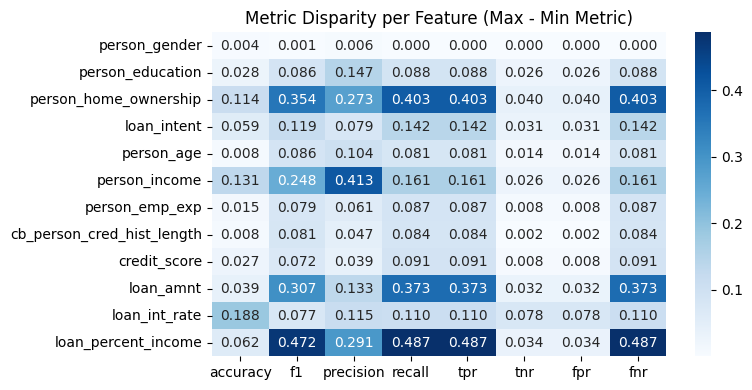

In [17]:
print("\n\nFairness Baseline Neural Network:\n")
fairness_nn_estimator = tuned_nn_estimator(baseline_neural_network)
fairness_nn_model = FairnessEnhancedModel(nn_train_df, nn_test_df, fairness_nn_estimator,
                                          sensitive_source_train_df=clean_train_df,
                                          sensitive_source_test_df=test_df,
                                          needs_encoding=False, model_name="neural_network", max_iter=20, show_plot=True)
fairness_nn_model.run()



Fairness SMOTE Neural Network:

Summary metrics (Test):
Accuracy: 0.8492
F1-score: 0.6613
Precision: 0.6602
Recall: 0.6625
TPR: 0.6625
TNR: 0.9026
FPR: 0.0974
FNR: 0.3375


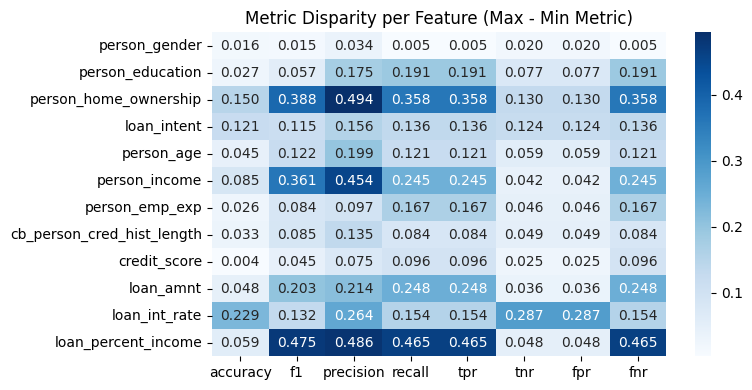

In [18]:
print("\n\nFairness SMOTE Neural Network:\n")
fairness_smote_nn_estimator = tuned_nn_estimator(smote_neural_network)
fairness_smote_nn_model = FairnessEnhancedModel(nn_smote_train_df, nn_smote_test_df, fairness_smote_nn_estimator,
                                                sensitive_source_train_df=smoted_train_df,
                                                sensitive_source_test_df=test_df,
                                                needs_encoding=False, model_name="neural_network_smote", max_iter=20, show_plot=True)
fairness_smote_nn_model.run()



Fairness QELM + Smote Neural Network:

Summary metrics (Test):
Accuracy: 0.8395
F1-score: 0.6426
Precision: 0.6363
Recall: 0.6490
TPR: 0.6490
TNR: 0.8940
FPR: 0.1060
FNR: 0.3510


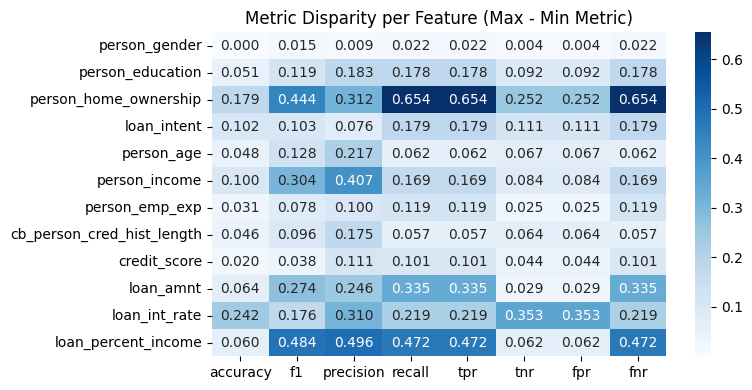

In [19]:
print("\n\nFairness QELM + Smote Neural Network:\n")
fairness_qelm_nn_estimator = tuned_nn_estimator(qelm_smote_neural_network)
fairness_qelm_nn_model = FairnessEnhancedModel(qelm_nn_train_df, qelm_nn_test_df, fairness_qelm_nn_estimator,
                                               sensitive_source_train_df=smoted_train_df,
                                               sensitive_source_test_df=test_df,
                                               needs_encoding=False, model_name="qelm_neural_network", max_iter=20, show_plot=True)
fairness_qelm_nn_model.run()